# Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv("tracks2026.csv")
print("Columns in df:")
print(df.columns.tolist())
df = df.drop(columns=['track_id'])
df = df.dropna()
df.head()

Columns in df:
['track_id', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop


## K-Means Clustering

In [3]:
# keep original genre columns for evaluation
df_original = df.copy()
df = df.drop(columns=['track_genre'])  

# OneHotEncode genre columns for evaluation later
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_genres = encoder.fit_transform(df_original[['track_genre']])

genre_feature_names = encoder.get_feature_names_out(['track_genre'])
genre_df = pd.DataFrame(
    encoded_genres, 
    columns=genre_feature_names,
    index=df_original.index
)


## Data Preparation

In [4]:
# Let us perform the preprosessing, same as in data preparation

# Define column groups
numerical_cols = df.select_dtypes(include=[np.number]).columns
categorical_numerical = ['key', 'mode', 'time_signature', 'explicit']  # numerical but categorical
continuous_numerical = [col for col in numerical_cols if col not in categorical_numerical]

no_outlier_cols = ['valence', 'acousticness']
outlier_cols = [col for col in continuous_numerical if col not in no_outlier_cols]
passthrough_cols = [col for col in df.columns if col not in continuous_numerical]

# Split outlier columns into negative and positive value groups
outlier_cols_neg = [col for col in outlier_cols if df[col].min() < 0]
outlier_cols_pos = [col for col in outlier_cols if df[col].min() >= 0]
# Pipelines
preprocess_no_outliers = Pipeline([
  #  ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

preprocess_outliers_neg = Pipeline([
    ('scaler', RobustScaler())  
])
preprocess_outliers_pos = Pipeline([
   #  ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
     ('scaler', RobustScaler())
])
# Scale key and time_signature columns, as they have different scale than others
key_timesignature_cols = ["key", "time_signature"]
key_timesignature_pipeline = Pipeline(steps = [
    ('scaler', StandardScaler())
])
minmax_pipeline = Pipeline(steps = [
    ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
    ('scaler', MinMaxScaler())
])
preprocess_pipeline = ColumnTransformer(
    transformers=[
        ('no_outliers', preprocess_no_outliers, no_outlier_cols),
        ('outliers_neg', preprocess_outliers_neg, outlier_cols_neg),
        ('outliers_pos', preprocess_outliers_pos, outlier_cols_pos),
        ('key_time_signature', key_timesignature_pipeline, key_timesignature_cols),
    ],
    remainder='passthrough'
)
print(no_outlier_cols)
print(outlier_cols_neg)
print(outlier_cols_pos)
print(key_timesignature_cols)



['valence', 'acousticness']
['loudness']
['popularity', 'duration_ms', 'danceability', 'energy', 'speechiness', 'instrumentalness', 'liveness', 'tempo']
['key', 'time_signature']


In [5]:
# step 2: drop genres from feature matrix and do clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

k = 4  # we got 4 genres

# Create Pipeline and fit Kmeans
kmeans_pipeline = Pipeline(steps=[
    ('preprocess', preprocess_pipeline),
    ('kmeans', KMeans(n_clusters=k, random_state=42, n_init='auto'))
])
kmeans_pipeline.fit(df)
cluster_labels_kmeans = kmeans_pipeline.named_steps['kmeans'].labels_

df['cluster'] = cluster_labels_kmeans
print("Cluster counts:\n", df['cluster'].value_counts())

# Process the features for PCA visualization
X_scaled = kmeans_pipeline.named_steps['preprocess'].transform(df.drop(columns=['cluster']))

Cluster counts:
 cluster
2    1812
0      94
1      29
3      25
Name: count, dtype: int64


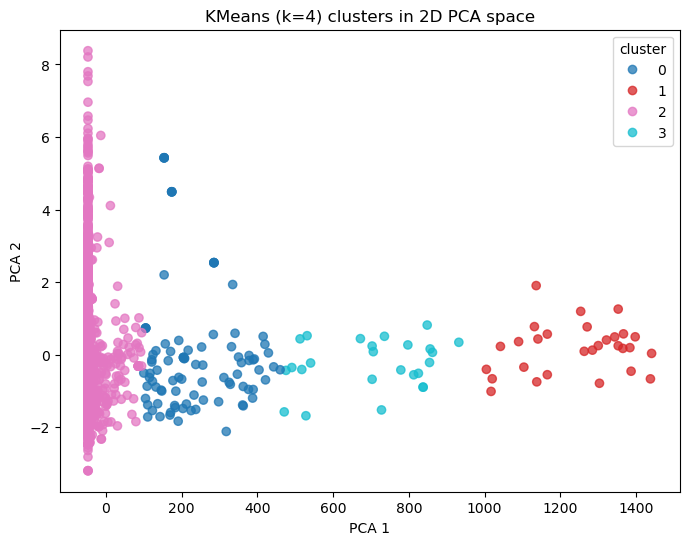

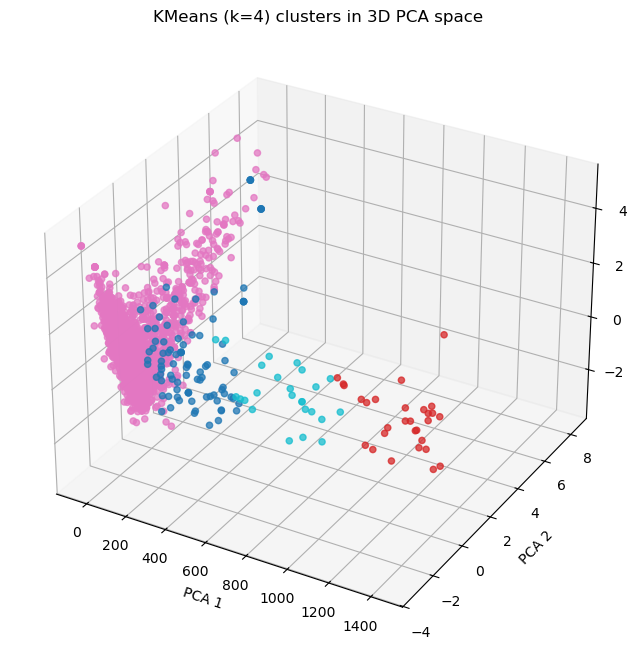

In [6]:


# 2D PCA plot for cluster visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels_kmeans, cmap='tab10', alpha=0.75)
plt.title(f"KMeans (k={k}) clusters in 2D PCA space")
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(*scatter.legend_elements(), title='cluster')
plt.show()

# 3D PCA plot for cluster visualization
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=cluster_labels_kmeans, cmap='tab10', alpha=0.75)
ax.set_title(f"KMeans (k={k}) clusters in 3D PCA space")
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
plt.show()

## Optimal Number of Clusters – Elbow & Silhouette

Before setting k=4 as a fixed value, the Elbow method and the silhouette score indicate whether this choice is appropriate.

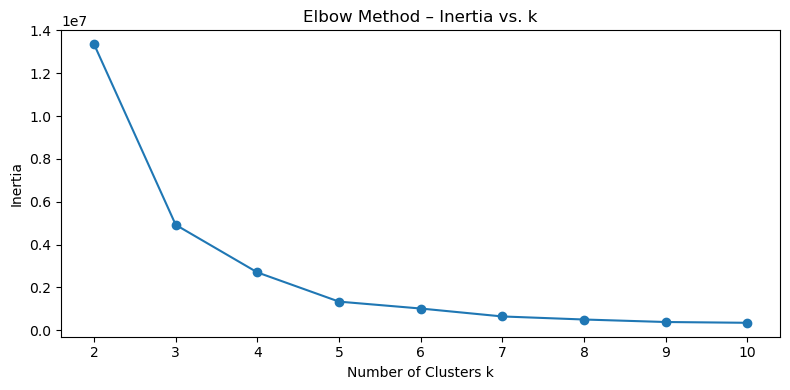

In [7]:
# Elbow Method – Inertia vs. k
inertias = []
K_range = range(2, 11)
for k_val in K_range:
    km = KMeans(n_clusters=k_val, random_state=42, n_init='auto')
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method – Inertia vs. k")
plt.xlabel("Number of Clusters k")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.tight_layout()
plt.show()

Based on the image above, we can see that there is a bend in the elbow around 3-4 characteristics, which makes sense as we know there are 4 different track-genres in the data set

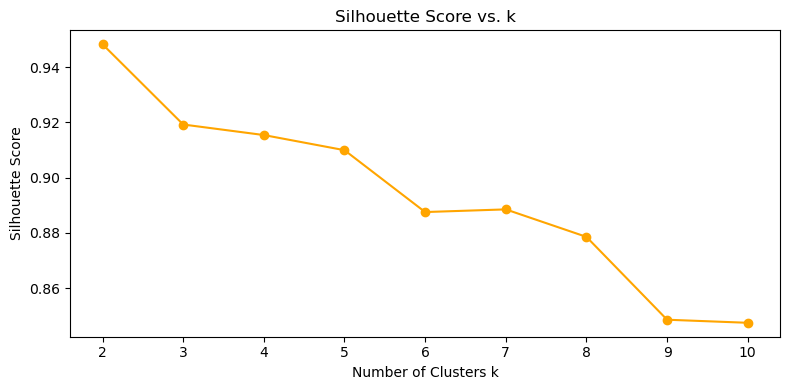

Best value of k by Silhouette Score: 2


In [8]:
from sklearn.metrics import silhouette_score

# Silhouette Score vs. k
sil_scores = []
for k_val in K_range:
    km = KMeans(n_clusters=k_val, random_state=42, n_init='auto')
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 4))
plt.plot(K_range, sil_scores, marker='o', color='orange')
plt.title("Silhouette Score vs. k")
plt.xlabel("Number of Clusters k")
plt.ylabel("Silhouette Score")
plt.xticks(K_range)
plt.tight_layout()
plt.show()

best_k = list(K_range)[sil_scores.index(max(sil_scores))]
print(f"Best value of k by Silhouette Score: {best_k}")

We find high silloughette scores near the 2-4 range again, supporting the fact that there around 4 genres in this data set.

## DBSCAN clustering

Cluster counts:
 cluster_dbscan
 0    1109
-1     795
 2      21
 1      15
 4      13
 3       7
Name: count, dtype: int64


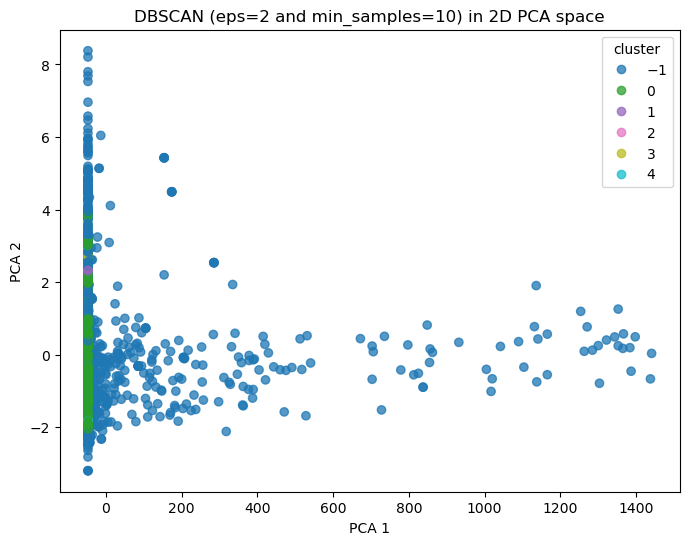

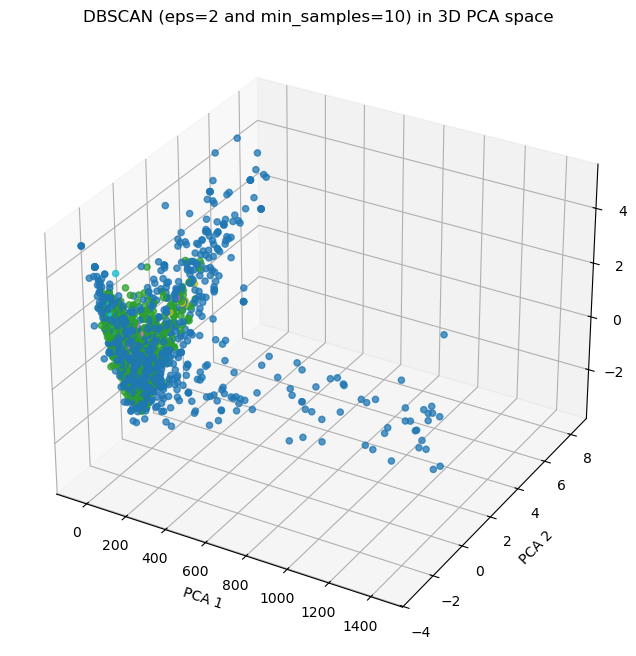

In [9]:
from sklearn.cluster import DBSCAN

# Configure two most important parameters: 
# eps = "radius of the circle for scanning"
# min_samples = "how many points in the neighbourhood in order to call it a core point"
eps = 2
min_samples = 10
dbscan = DBSCAN(eps=eps, min_samples=min_samples)

# use same X_scaled as in KMeans
# fit DBSCAN
cluster_labels_dbscan = dbscan.fit_predict(X_scaled)

# Continue in a same way than with KMeans

df['cluster_dbscan'] = cluster_labels_dbscan
print("Cluster counts:\n", df['cluster_dbscan'].value_counts())

# 2D PCA plot for cluster visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels_dbscan, cmap='tab10', alpha=0.75)
plt.title(f"DBSCAN (eps={eps} and min_samples={min_samples}) in 2D PCA space")
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(*scatter.legend_elements(), title='cluster')
plt.show()

# 3D PCA plot for cluster visualization
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=cluster_labels_dbscan, cmap='tab10', alpha=0.75)
ax.set_title(f"DBSCAN (eps={eps} and min_samples={min_samples}) in 3D PCA space")
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
plt.show()

In [10]:
# Number of clusters (= unique values -1, as "-1" is labelled as noise)
n_clusters = len(dict.fromkeys(cluster_labels_dbscan))-1
print(f"Cluster class -1 is for noise/outlier points. As can be seen, with DBSCAN with parameters eps={eps} and min_samples={min_samples}, we find {n_clusters} clusters + noise. \n Almost half of the data is noise, indicating DBSCAN may not be the most suitable algorithm for this application.")

Cluster class -1 is for noise/outlier points. As can be seen, with DBSCAN with parameters eps=2 and min_samples=10, we find 5 clusters + noise. 
 Almost half of the data is noise, indicating DBSCAN may not be the most suitable algorithm for this application.


In [11]:
# == Cluster quality against original genre columns from df_transformed ==

# Cannot be done to DBSCAN results, as number of clusters is not predetermined.


# Merge cluster assignments with original genre columns
merged = df_original.copy()
merged['cluster'] = cluster_labels_kmeans

# Add the encoded genre columns to merged
for col in genre_feature_names:
    merged[col] = genre_df[col]

# Find genre features with max values
merged['predicted_genre'] = merged[genre_feature_names].idxmax(axis=1).str.replace("track_genre_", "")

# show composition per cluster
cluster_genre = (
    merged.groupby(["cluster", "predicted_genre"]).size().reset_index(name="count")
    .sort_values(["cluster", "count"], ascending=[True, False])
)
print("Cluster vs Genre composition:")
print(cluster_genre)

# compute majority genre accuracy per cluster
cluster_total = cluster_genre.groupby("cluster")["count"].sum().rename("total")
cluster_top = (
    cluster_genre.groupby("cluster").first().rename(columns={"count": "top_count"})
    .reset_index()
    .set_index("cluster")["top_count"]
)
cluster_summary = pd.concat([cluster_total, cluster_top], axis=1)
cluster_summary["cluster_majority_pct"] = cluster_summary["top_count"] / cluster_summary["total"]

print("\nCluster majority genre accuracy:\n", cluster_summary)

# overall purity estimate
total_matches = cluster_summary["top_count"].sum()
purity = total_matches / len(merged)
print(f"\nOverall clustering purity (proxy accuracy): {purity:.4f}")

# view first 100 rows with cluster and genre
print("\n\nFirst 100 rows - cluster vs predicted genre:")
display(merged[["cluster", "predicted_genre"]].head(100))

Cluster vs Genre composition:
    cluster predicted_genre  count
4         0       synth-pop     43
1         0       indie-pop     21
2         0             pop     18
0         0         hip-hop      7
3         0           r-n-b      5
8         1       synth-pop     16
5         1       indie-pop      9
6         1             pop      3
7         1           r-n-b      1
11        2             pop    465
10        2       indie-pop    454
13        2       synth-pop    322
12        2           r-n-b    287
9         2         hip-hop    284
17        3       synth-pop     12
15        3       indie-pop     10
16        3             pop      2
14        3         hip-hop      1

Cluster majority genre accuracy:
          total  top_count  cluster_majority_pct
cluster                                        
0           94         43              0.457447
1           29         16              0.551724
2         1812        465              0.256623
3           25         12     

,cluster,predicted_genre
0,2,r-n-b
1,2,pop
2,2,synth-pop
3,2,indie-pop
4,2,synth-pop
...,...,...
98,2,hip-hop
100,2,indie-pop
101,0,indie-pop
102,2,pop



Genre % composition per cluster:
predicted_genre  hip-hop  indie-pop    pop  r-n-b  synth-pop
cluster                                                     
0                   7.45      22.34  19.15   5.32      45.74
1                   0.00      31.03  10.34   3.45      55.17
2                  15.67      25.06  25.66  15.84      17.77
3                   4.00      40.00   8.00   0.00      48.00


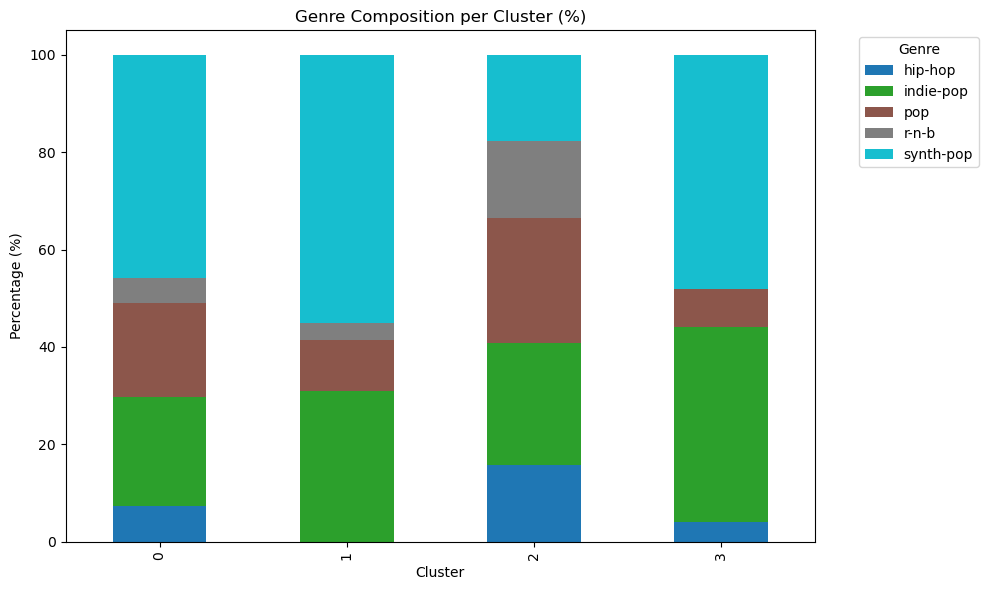

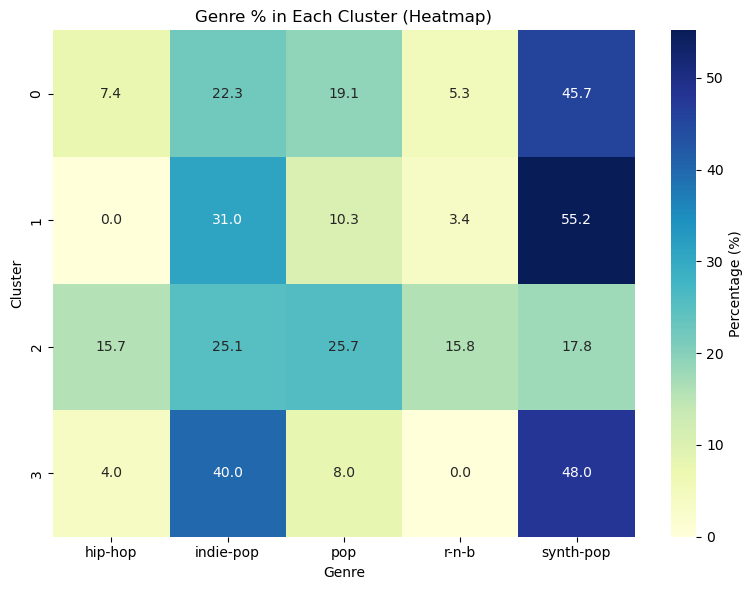


📊 Interpretation:
- Each row represents a cluster
- Each column represents a genre
- High concentration in one genre = good cluster purity
- Mixed percentages = clusters don't cleanly separate genres
- KMeans clustering is in this application more appropriate, as the number of clusters is known


In [ ]:
import seaborn as sns

# create pivot table: cluster x genre with percentages
cluster_genre_pivot = cluster_genre.pivot_table(
    index="cluster", 
    columns="predicted_genre", 
    values="count", 
    fill_value=0
)

# convert to percentage per cluster (row-wise normalization)
cluster_genre_pct = cluster_genre_pivot.div(cluster_genre_pivot.sum(axis=1), axis=0) * 100

print("\nGenre % composition per cluster:")
print(cluster_genre_pct.round(2))

# stacked bar chart: cluster vs % genre composition
fig, ax = plt.subplots(figsize=(10, 6))
cluster_genre_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title("Genre Composition per Cluster (%)")
ax.set_xlabel("Cluster")
ax.set_ylabel("Percentage (%)")
ax.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# heatmap: cluster x genre percentages
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cluster_genre_pct, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Percentage (%)'}, ax=ax)
ax.set_title("Genre % in Each Cluster (Heatmap)")
ax.set_xlabel("Genre")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.show()


## Conclusion
Fitting a clustering agorithm to this model also showed harder results, this could likely be because genres have a hard time being put into certain characteristics, also there being an abundance of certain genres over others could explain the difficulty.